# XAI 기반 OTT 신규 고객 이탈 요인 분석

## 분석 흐름
1. 데이터 로드 및 피처 엔지니어링
2. 이탈 예측 모델 (XGBoost)
3. SHAP 분석 (XAI)
4. 핵심 이탈 요인 시각화

**타겟 변수**: `is_repurchase` (0 = 이탈, 1 = 재구매)

In [85]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE = Path('../data/02_interim/260504_promotion_split')

membership   = pd.concat([
    pd.read_csv(BASE / 'promotion_0_membership_v2.csv', encoding='utf-8-sig'),
    pd.read_csv(BASE / 'promotion_1_membership_v2.csv', encoding='utf-8-sig'),
], ignore_index=True)

user_mapping = pd.concat([
    pd.read_csv(BASE / 'promotion_0_user_mapping_v2.csv', encoding='utf-8-sig'),
    pd.read_csv(BASE / 'promotion_1_user_mapping_v2.csv', encoding='utf-8-sig'),
], ignore_index=True).drop_duplicates()

view_history = pd.concat([
    pd.read_csv(BASE / 'promotion_0_view_history_v2.csv', encoding='utf-8-sig'),
    pd.read_csv(BASE / 'promotion_1_view_history_v2.csv', encoding='utf-8-sig'),
], ignore_index=True).drop_duplicates()

print('membership:  ', membership.shape)
print('user_mapping:', user_mapping.shape)
print('view_history:', view_history.shape)

membership:   (14873, 15)
user_mapping: (14668, 2)
view_history: (104747, 5)


## 1. 피처 엔지니어링
### 1-1. Membership 피처

In [86]:
mem = membership.copy()

# 구독 기간
mem['duration_days'] = (
    pd.to_datetime(mem['end_date']) - pd.to_datetime(mem['reg_date'])
).dt.days

# 가입 시간대 구분
mem['reg_hour_group'] = pd.cut(
    mem['reg_hour'], bins=[-1, 5, 11, 17, 23],
    labels=[0, 1, 2, 3]  # 새벽/오전/오후/저녁
).astype(int)

# 연령대
mem['age_group'] = pd.cut(
    mem['age'], bins=[14, 19, 29, 39, 49, 70],
    labels=[0, 1, 2, 3, 4]
).astype(int)

# 100원 프로모션 여부
mem['is_100'] = (mem['price'] == 100).astype(int)

# 성별 인코딩
mem['gender_enc'] = mem['gender'].map({'F': 0, 'M': 1}).fillna(2).astype(int)

# payment_device 인코딩
device_map = {d: i for i, d in enumerate(mem['payment_device'].unique())}
mem['device_enc'] = mem['payment_device'].map(device_map).astype(int)

print('membership 피처 생성 완료')
mem[['USER_KEY', 'duration_days', 'reg_hour_group', 'age_group', 'is_100',
     'gender_enc', 'device_enc', 'is_promotion', 'is_repurchase', 'max_screen',
     'billing_method', 'is_user_verified']].head(3)

membership 피처 생성 완료


,USER_KEY,duration_days,reg_hour_group,age_group,is_100,gender_enc,device_enc,is_promotion,is_repurchase,max_screen,billing_method,is_user_verified
0,3c1f896f1bba7572b29d388a07e01e86fb0d3fbfe51608...,32,1,3,0,2,0,0,1,2,140,0
1,21026cbc660d69f02985f06f89311143560d14f56da617...,31,1,2,0,0,1,0,1,2,151,1
2,2c9e3f9186e5dcd624c026c3a72b3070a03822476c6d1c...,31,0,4,0,1,1,0,0,1,134,1


### 1-2. View_History 집계 피처

In [87]:
# USER_NUM → USER_KEY 매핑
vh = view_history.merge(user_mapping, on='USER_NUM', how='left')

# 유저별 시청 집계
vh_agg = vh.groupby('USER_KEY').agg(
    watch_count      = ('watch_seq', 'count'),           # 총 시청 횟수
    total_watch_time = ('watch_time(min)', 'sum'),        # 총 시청 시간
    avg_watch_time   = ('watch_time(min)', 'mean'),       # 평균 시청 시간
    unique_movies    = ('MOVIE_NUM', 'nunique'),          # 고유 영화 수
    watch_days       = ('watch_day', 'nunique'),          # 시청한 날짜 수
    last_watch_day   = ('watch_day', 'max'),              # 마지막 시청일
    first_watch_day  = ('watch_day', 'min'),              # 첫 시청일
).reset_index()

# 시청 기간 (마지막 - 첫 시청일)
vh_agg['watch_span'] = vh_agg['last_watch_day'] - vh_agg['first_watch_day']

# 시청 집중도 (총 시청일 / 시청 기간)
vh_agg['watch_density'] = vh_agg['watch_days'] / (vh_agg['watch_span'] + 1)

# 영화 다양성 (고유 영화 / 총 시청 횟수)
vh_agg['movie_diversity'] = vh_agg['unique_movies'] / vh_agg['watch_count']

print('view_history 집계 피처 생성 완료')
print(f'집계 유저 수: {len(vh_agg):,}명')
vh_agg.head(3)

view_history 집계 피처 생성 완료
집계 유저 수: 14,631명


,USER_KEY,watch_count,total_watch_time,avg_watch_time,unique_movies,watch_days,last_watch_day,first_watch_day,watch_span,watch_density,movie_diversity
0,0000555c21e7942b8281c8068c2b5be0a628b8a1a3cbea...,15,445,29.666667,7,10,20210322,20210306,16,0.588235,0.466667
1,0006075c3c18078eb09940cd27c6359a96a2a17fce8055...,5,452,90.400000,4,3,20210324,20210311,13,0.214286,0.800000
2,0008a7c034e8493a4b98463eddd53fd39de41f820dbd76...,4,111,27.750000,4,4,20210317,20210312,5,0.666667,1.000000


### 1-3. 최종 피처 테이블 병합

In [88]:
df = mem.merge(vh_agg, on='USER_KEY', how='left')

# 시청 피처 결측 = 시청 없음 → 0으로
view_cols = ['watch_count', 'total_watch_time', 'avg_watch_time',
             'unique_movies', 'watch_days', 'watch_span',
             'watch_density', 'movie_diversity']
df[view_cols] = df[view_cols].fillna(0)

print(f'최종 데이터: {df.shape}')
print(f'\n타겟 분포 (is_repurchase):')
print(df['is_repurchase'].value_counts())
print(f'\n이탈률: {(df["is_repurchase"]==0).mean()*100:.1f}%')

최종 데이터: (14873, 31)

타겟 분포 (is_repurchase):
is_repurchase
1    9830
0    5043
Name: count, dtype: int64

이탈률: 33.9%


## 2. 이탈 예측 모델 (XGBoost)

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb

FEATURES = [
    # 구독 피처
    'duration_days', 'is_100', 'is_promotion', 'max_screen',
    'billing_method', 'is_user_verified', 'reg_hour_group',
    'age_group', 'gender_enc', 'device_enc',
    # 시청 피처
    'watch_count', 'total_watch_time', 'avg_watch_time',
    'unique_movies', 'watch_days', 'watch_span',
    'watch_density', 'movie_diversity',
]
TARGET = 'is_repurchase'

X = df[FEATURES].fillna(0)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('=' * 50)
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['이탈(0)', '재구매(1)']))

AUC-ROC: 0.6744
              precision    recall  f1-score   support

       이탈(0)       0.64      0.22      0.33      1009
      재구매(1)       0.70      0.94      0.80      1966

    accuracy                           0.69      2975
   macro avg       0.67      0.58      0.56      2975
weighted avg       0.68      0.69      0.64      2975



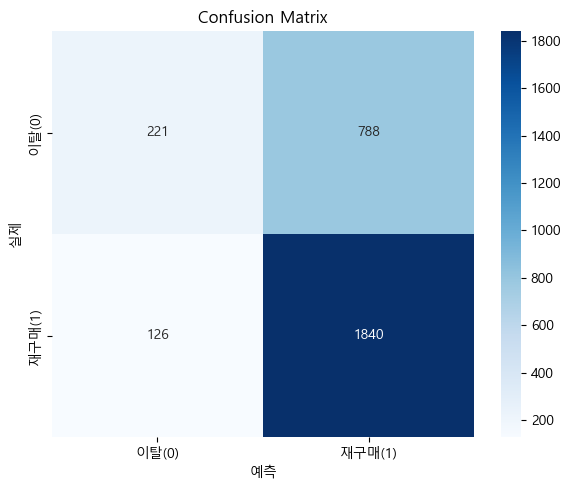

In [90]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['이탈(0)', '재구매(1)'],
            yticklabels=['이탈(0)', '재구매(1)'])
ax.set_title('Confusion Matrix')
ax.set_xlabel('예측')
ax.set_ylabel('실제')
plt.tight_layout()
plt.show()

## 3. SHAP 분석 (XAI)
### 3-1. 전체 변수 중요도 (Global SHAP)

In [91]:
import subprocess, sys

pkgs = [
    'numpy==1.26.4',
    'numba==0.59.1',
    'llvmlite==0.42.0',
    'slicer==0.0.7',
    'cloudpickle',
    'shap==0.44.0',
]
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('shap 설치 완료')

shap 설치 완료


In [92]:
import shap

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)   # (n_samples, n_features)

# 한글 변수명 매핑
feature_names_kr = {
    'duration_days'    : '구독기간(일)',
    'is_100'           : '100원 프로모션',
    'is_promotion'     : '프로모션 여부',
    'max_screen'       : '동시접속 화면수',
    'billing_method'   : '결제방식',
    'is_user_verified' : '본인인증 여부',
    'reg_hour_group'   : '가입 시간대',
    'age_group'        : '연령대',
    'gender_enc'       : '성별',
    'device_enc'       : '결제기기',
    'watch_count'      : '총 시청 횟수',
    'total_watch_time' : '총 시청 시간(분)',
    'avg_watch_time'   : '평균 시청 시간',
    'unique_movies'    : '고유 영화 수',
    'watch_days'       : '시청 일수',
    'watch_span'       : '시청 기간',
    'watch_density'    : '시청 집중도',
    'movie_diversity'  : '영화 다양성',
}
feat_names_kr_list = [feature_names_kr.get(f, f) for f in FEATURES]
X_test_kr = X_test.rename(columns=feature_names_kr)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_kr, plot_type='bar', show=False)
plt.title('전체 변수 중요도 (Global SHAP)', fontsize=14)
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: '[6.6095144E-1]'

### 3-2. 변수별 영향 방향 (Beeswarm Plot)

In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_kr, show=False)
plt.title('변수 영향 방향 (높을수록 재구매 가능성 ↑)', fontsize=13)
plt.tight_layout()
plt.show()

### 3-3. 핵심 변수 의존성 분석 (Dependence Plot)

In [ ]:
# 상위 4개 변수 의존성 분석
mean_shap = np.abs(shap_values).mean(axis=0)
top4_idx  = mean_shap.argsort()[::-1][:4]
top4_cols = [FEATURES[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), top4_cols):
    col_idx = FEATURES.index(col)
    shap.dependence_plot(
        col_idx, shap_values, X_test,
        feature_names=[feature_names_kr.get(f, f) for f in FEATURES],
        ax=ax, show=False
    )
plt.suptitle('핵심 변수 의존성 분석', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3-4. 개별 고객 예측 설명 (Local SHAP Waterfall)

In [ ]:
# 이탈 예측 고객 1명 설명 (Waterfall)
churn_idx = np.where((y_pred == 0) & (y_test.values == 0))[0][0]

explanation = shap.Explanation(
    values        = shap_values[churn_idx],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[churn_idx].values,
    feature_names = feat_names_kr_list,
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=False)
plt.title('이탈 예측 고객 - 개별 설명 (Waterfall)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. 이탈 요인 요약

In [ ]:
# 변수 중요도 순위 테이블
mean_shap_vals = np.abs(shap_values).mean(axis=0)
importance_df  = pd.DataFrame({
    '변수': [feature_names_kr.get(f, f) for f in FEATURES],
    '원래 변수명': FEATURES,
    'SHAP 중요도': mean_shap_vals
}).sort_values('SHAP 중요도', ascending=False).reset_index(drop=True)

importance_df.index += 1
print('=' * 50)
print('[ 이탈 요인 중요도 순위 ]')
print('=' * 50)
print(importance_df[['변수', 'SHAP 중요도']].to_string())

# 시각화
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(importance_df))]
ax.barh(importance_df['변수'][::-1], importance_df['SHAP 중요도'][::-1], color=colors[::-1])
ax.set_title('이탈 요인 중요도 (SHAP 기반)', fontsize=14)
ax.set_xlabel('SHAP 중요도')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()